In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = sns.load_dataset('titanic')


print("Dimensões:", df.shape)

df.head()

Dimensões: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Análise Exploratória de Dados

In [ ]:
# Verificar informações gerais do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
# Estatísticas descritivas do dataset
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


O dataset possui 891 registros de passageiros do Titanic

Deles aproximadamente 38,38% dos passageiros sobreviveram ao naufrágio

A idade média dos passageiros com idade registrada foi de 29,70 anos, com mediana de 28 anos e desvio padrão de 14,53 anos.

Analisando o valor das passagens, encontramos uma média de 32,20 e mediana de 14,45

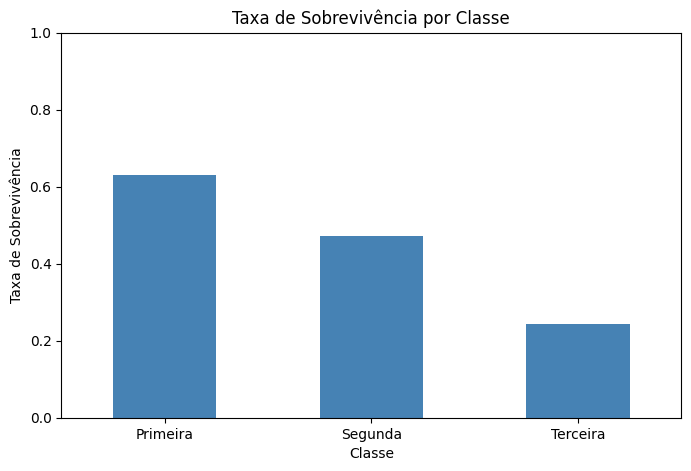

In [5]:
# Taxa de sobrevivência por classe
taxa_classe = df.groupby('class', observed=True)['survived'].mean()

taxa_classe.index = ['Primeira', 'Segunda', 'Terceira']

plt.figure(figsize=(8, 5))

taxa_classe.plot(kind='bar', color='steelblue')

plt.title('Taxa de Sobrevivência por Classe')
plt.xlabel('Classe')
plt.ylabel('Taxa de Sobrevivência')
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.show()

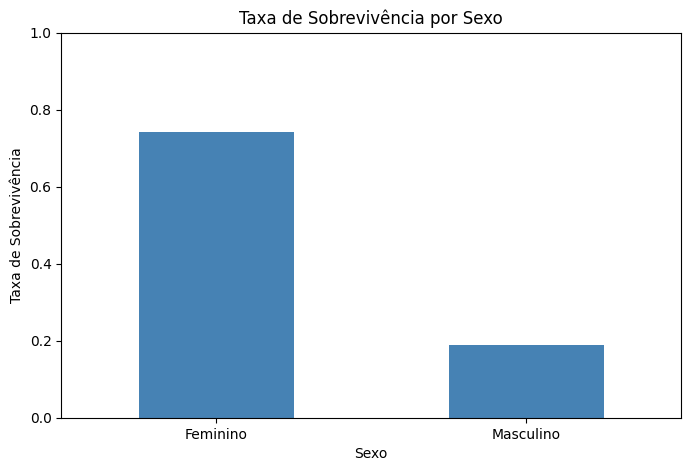

In [6]:
# Taxa de sobrevivência por sexo
taxa_sexo = df.groupby('sex')['survived'].mean()

taxa_sexo.index = ['Feminino', 'Masculino']

plt.figure(figsize=(8, 5))

taxa_sexo.plot(kind='bar', color='steelblue')

plt.title('Taxa de Sobrevivência por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Taxa de Sobrevivência')
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.show()

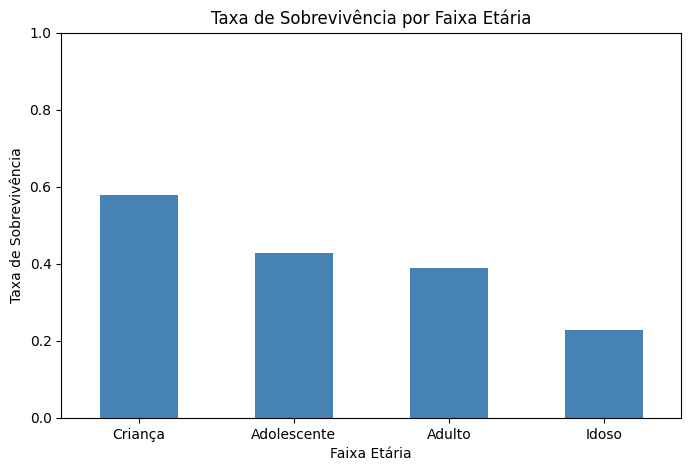

In [7]:
faixas = [0, 12, 18, 60, 100]
categorias = ['Criança', 'Adolescente', 'Adulto', 'Idoso']

df['faixa_etaria'] = pd.cut(
    df['age'],
    bins=faixas,
    labels=categorias,
    include_lowest=True
)

# taxa de sobrevivência por faixa etária
taxa_idade = df.groupby('faixa_etaria', observed=True)['survived'].mean()


plt.figure(figsize=(8, 5))

taxa_idade.plot(kind='bar', color='steelblue')

plt.title('Taxa de Sobrevivência por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Taxa de Sobrevivência')
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.show()

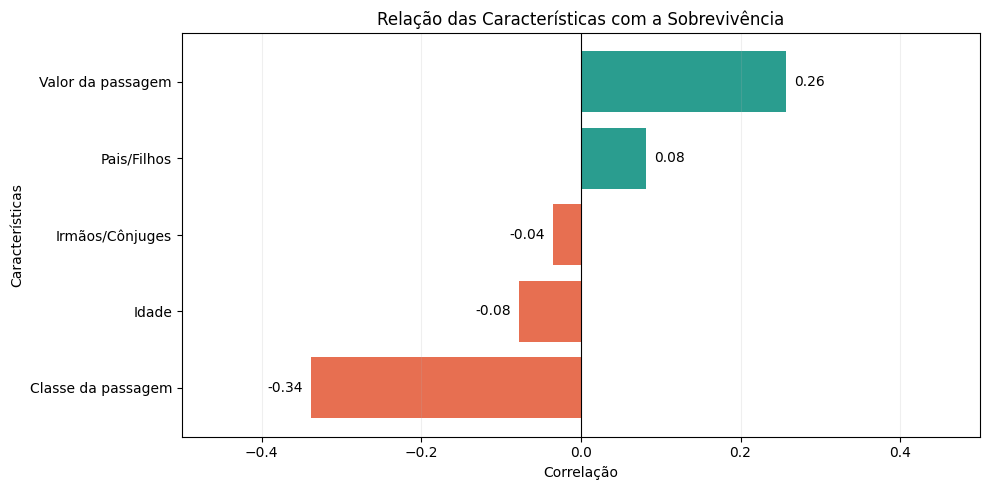

In [9]:
colunas = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

# Calcular correlação com a sobrevivência
correlacoes = df[colunas].corr()['survived'].drop('survived')


correlacoes.index = [
    'Classe da passagem',
    'Idade',
    'Irmãos/Cônjuges',
    'Pais/Filhos',
    'Valor da passagem'
]

correlacoes = correlacoes.sort_values()


plt.figure(figsize=(10, 5))

cores = ['#e76f51' if valor < 0 else '#2a9d8f'
         for valor in correlacoes]

barras = plt.barh(correlacoes.index, correlacoes.values, color=cores)

for barra, valor in zip(barras, correlacoes.values):
    plt.text(
        valor + (0.01 if valor >= 0 else -0.01),
        barra.get_y() + barra.get_height() / 2,
        f'{valor:.2f}',
        va='center',
        ha='left' if valor >= 0 else 'right'
    )

plt.title('Relação das Características com a Sobrevivência')
plt.xlabel('Correlação')
plt.ylabel('Características')
plt.xlim(-0.5, 0.5)
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

# Tratamento e Limpeza dos Dados

In [10]:
# Verificar valores ausentes em cada coluna
valores_ausentes = df.isnull().sum()

# Mostrar apenas colunas com valores ausentes
print(valores_ausentes[valores_ausentes > 0])

age             177
embarked          2
deck            688
embark_town       2
faixa_etaria    177
dtype: int64


In [12]:
# Calcular a mediana das idades
mediana_idade = df['age'].median()

# Preencher idades ausentes com a mediana
df['age'] = df['age'].fillna(mediana_idade)

print("Mediana utilizada:", mediana_idade)
print("Idades ausentes após tratamento:", df['age'].isnull().sum())

Mediana utilizada: 28.0
Idades ausentes após tratamento: 0


In [13]:
# Identificar os valores mais frequentes
moda_embarked = df['embarked'].mode()[0]
moda_embark_town = df['embark_town'].mode()[0]

# Preencher os valores ausentes
df['embarked'] = df['embarked'].fillna(moda_embarked)
df['embark_town'] = df['embark_town'].fillna(moda_embark_town)

print("Porto mais frequente:", moda_embarked)
print("Cidade mais frequente:", moda_embark_town)

print("Valores ausentes em embarked:", df['embarked'].isnull().sum())
print("Valores ausentes em embark_town:", df['embark_town'].isnull().sum())

Porto mais frequente: S
Cidade mais frequente: Southampton
Valores ausentes em embarked: 0
Valores ausentes em embark_town: 0


In [14]:
# Remover a coluna deck
df = df.drop(columns=['deck'])

# Verificar
print("Quantidade de colunas:", df.shape[1])
print("Coluna deck existe?", 'deck' in df.columns)

Quantidade de colunas: 15
Coluna deck existe? False


In [15]:
# Definir as faixas etárias
faixas = [0, 12, 18, 60, 100]
categorias = ['Criança', 'Adolescente', 'Adulto', 'Idoso']

# Atualizar a coluna faixa_etaria
df['faixa_etaria'] = pd.cut(
    df['age'],
    bins=faixas,
    labels=categorias,
    include_lowest=True
)

print("Valores ausentes por coluna:")
print(df.isnull().sum())

Valores ausentes por coluna:
survived        0
pclass          0
sex             0
age             0
sibsp           0
parch           0
fare            0
embarked        0
class           0
who             0
adult_male      0
embark_town     0
alive           0
alone           0
faixa_etaria    0
dtype: int64


In [16]:
# Verificar registros duplicados
duplicados = df.duplicated().sum()

print("Quantidade de registros duplicados:", duplicados)

Quantidade de registros duplicados: 116


In [17]:
# Mostrar alguns registros identificados como duplicados
df[df.duplicated(keep=False)].head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,faixa_etaria
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,Adulto
23,1,1,male,28.0,0,0,35.5000,S,First,man,True,Southampton,yes,True,Adulto
26,0,3,male,28.0,0,0,7.2250,C,Third,man,True,Cherbourg,no,True,Adulto
28,1,3,female,28.0,0,0,7.8792,Q,Third,woman,False,Queenstown,yes,True,Adulto
29,0,3,male,28.0,0,0,7.8958,S,Third,man,True,Southampton,no,True,Adulto
32,1,3,female,28.0,0,0,7.7500,Q,Third,woman,False,Queenstown,yes,True,Adulto
37,0,3,male,21.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,Adulto
42,0,3,male,28.0,0,0,7.8958,C,Third,man,True,Cherbourg,no,True,Adulto
45,0,3,male,28.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,Adulto
46,0,3,male,28.0,1,0,15.5000,Q,Third,man,True,Queenstown,no,False,Adulto


mantive os 891 passageiros, pois não temos um id que permita confirmar quais registros realmente representam a mesma pessoa

In [18]:
# Verificar possíveis inconsistências

print("Idades negativas:", (df['age'] < 0).sum())

print("Idades acima de 120 anos:", (df['age'] > 120).sum())

print("Passagens com valores negativos:", (df['fare'] < 0).sum())

print("Classes inválidas:", (~df['pclass'].isin([1, 2, 3])).sum())

print("Irmãos/cônjuges negativos:", (df['sibsp'] < 0).sum())

print("Pais/filhos negativos:", (df['parch'] < 0).sum())

Idades negativas: 0
Idades acima de 120 anos: 0
Passagens com valores negativos: 0
Classes inválidas: 0
Irmãos/cônjuges negativos: 0
Pais/filhos negativos: 0


1. Identifiquei **valores ausentes** nas colunas age, embarked, embark_town e deck

Para corrigir esses problemas, substitui as idades ausentes pela mediana de 28 anos e preenchi os portos de embarque utilizando os valores mais frequentes

A coluna deck foi removida porque apresentava aproximadamente 77% de valores ausentes

2. Identificados 116 **registros duplicados** após o tratamento. Optei por manter as duplicatas, pois não existe um identificador único que permita confirmar se representam o mesmo passageiro.

3. Verificamos possíveis inconsistências, como idades negativas, valores de passagens inválidos e classes inexistentes e **nenhuma dessas inconsistências foi encontrada**

Após o tratamento, o dataset permaneceu com 891 registros e 15 colunas, sem valores ausentes

# Feature Engineering

In [19]:
# Criar a coluna tamanho_familia
df['tamanho_familia'] = df['sibsp'] + df['parch'] + 1

df[['sibsp', 'parch', 'tamanho_familia']].head(10)

,sibsp,parch,tamanho_familia
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
5,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2


In [20]:
# Criar variável binária
df['viajava_sozinho'] = (df['tamanho_familia'] == 1).astype(int)

df[['tamanho_familia', 'viajava_sozinho']].head(10)

,tamanho_familia,viajava_sozinho
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
5,1,1
6,1,1
7,5,0
8,3,0
9,2,0


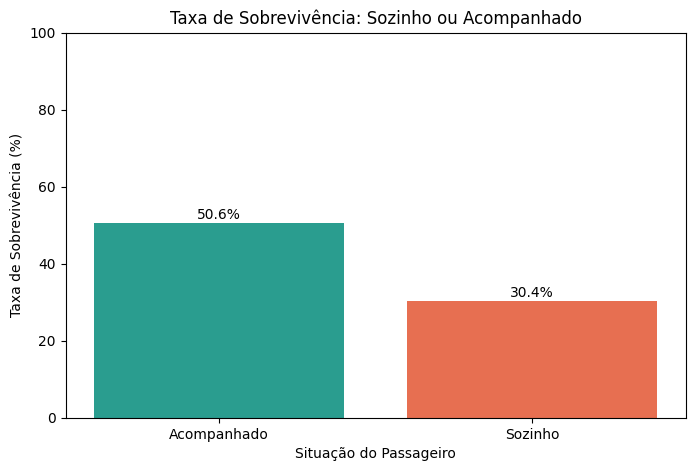

In [21]:
# Calcular a taxa de sobrevivência
taxa_sozinho = df.groupby('viajava_sozinho')['survived'].mean() * 100

taxa_sozinho.index = ['Acompanhado', 'Sozinho']

plt.figure(figsize=(8, 5))

barras = plt.bar(
    taxa_sozinho.index,
    taxa_sozinho.values,
    color=['#2a9d8f', '#e76f51']
)

for barra in barras:
    altura = barra.get_height()

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 1,
        f'{altura:.1f}%',
        ha='center'
    )

plt.title('Taxa de Sobrevivência: Sozinho ou Acompanhado')
plt.xlabel('Situação do Passageiro')
plt.ylabel('Taxa de Sobrevivência (%)')
plt.ylim(0, 100)

plt.show()